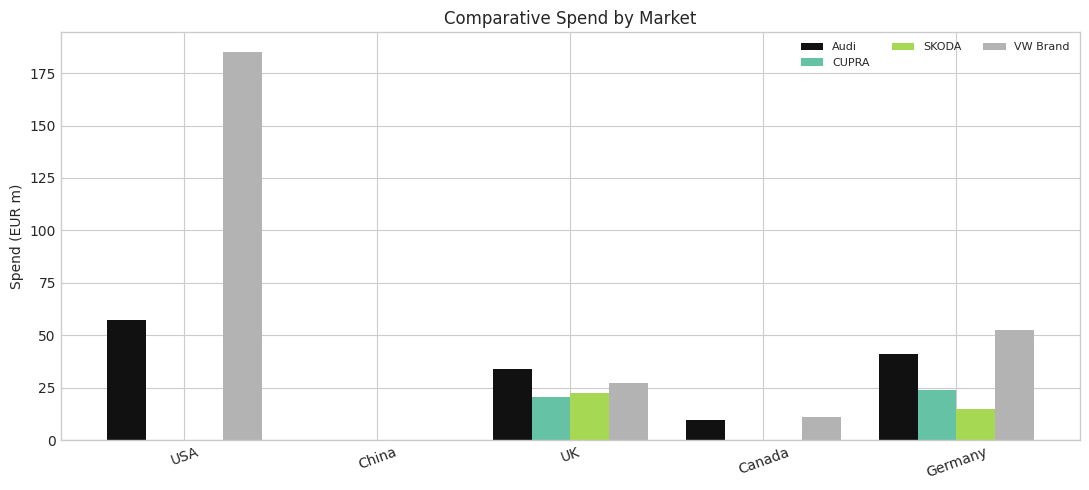

In [ ]:
# 1) Comparative spend by market
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')

MAPPE = Path('/home/ali/repos/porsche/budget_setting/highlight_budget_estimation/budget_setting_amendment/Mappe1.xlsx')

df = pd.read_excel(MAPPE, sheet_name='2024', header=6)
df.columns = [str(c).strip() for c in df.columns]
df = df.rename(columns={
    'Brand': 'brand_raw',
    'Market': 'market',
    'Media': 'media',
    'Sum of 2024 CY (EUR)': 'spend_eur'
})[['brand_raw', 'market', 'media', 'spend_eur']]

df['spend_eur'] = pd.to_numeric(df['spend_eur'], errors='coerce')
for c in ['brand_raw', 'market', 'media']:
    df[c] = df[c].astype(str).str.strip()

df = df[df['spend_eur'].notna() & (df['spend_eur'] > 0)].copy()

split = df['brand_raw'].str.extract(r'^(?P<brand>.*?)\s*-\s*Tier\s*(?P<tier>\d+)$')
df['brand'] = split['brand'].str.strip()
df['tier'] = pd.to_numeric(split['tier'], errors='coerce')

df = df[df['tier'] == 1].copy()
df = df[~df['brand_raw'].str.contains('Total|Grand Total', case=False, na=False)].copy()
df = df[~df['market'].str.contains('Total', case=False, na=False)].copy()

porsche_markets = sorted(df.loc[df['brand'].str.upper() == 'PORSCHE', 'market'].unique())
df = df[df['market'].isin(porsche_markets)].copy()

# keep main markets only (top 5 Porsche spend)
porsche_market = df[df['brand'].str.upper() == 'PORSCHE'].groupby('market', as_index=False)['spend_eur'].sum()
main_markets = porsche_market.sort_values('spend_eur', ascending=False).head(5)['market'].tolist()
plot = df[df['market'].isin(main_markets)].copy()

# keep Porsche + top 4 VW brands for readability
comp_rank = plot[plot['brand'].str.upper() != 'PORSCHE'].groupby('brand', as_index=False)['spend_eur'].sum().sort_values('spend_eur', ascending=False)
keep_brands = ['PORSCHE'] + comp_rank.head(4)['brand'].tolist()
plot = plot[plot['brand'].isin(keep_brands)].copy()

mat = plot.groupby(['market', 'brand'], as_index=False)['spend_eur'].sum().pivot(index='market', columns='brand', values='spend_eur').fillna(0)
mat = mat.reindex(main_markets)
cols = [c for c in ['PORSCHE'] + [x for x in mat.columns if x != 'PORSCHE'] if c in mat.columns]
mat = mat[cols] / 1e6

x = np.arange(len(mat.index))
n = len(mat.columns)
width = min(0.8 / n, 0.2)
colors = ['#111111'] + list(plt.cm.Set2(np.linspace(0, 1, max(n - 1, 1))))

fig, ax = plt.subplots(figsize=(11, 5))
for i, c in enumerate(mat.columns):
    off = (i - (n - 1) / 2) * width
    ax.bar(x + off, mat[c].values, width=width, label=c, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(mat.index, rotation=20)
ax.set_ylabel('Spend (EUR m)')
ax.set_title('Comparative Spend by Market')
ax.legend(frameon=False, ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

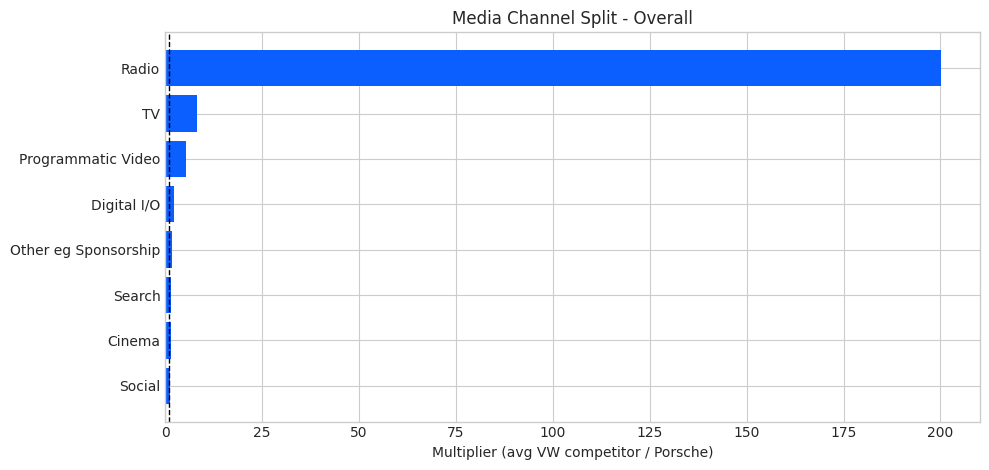

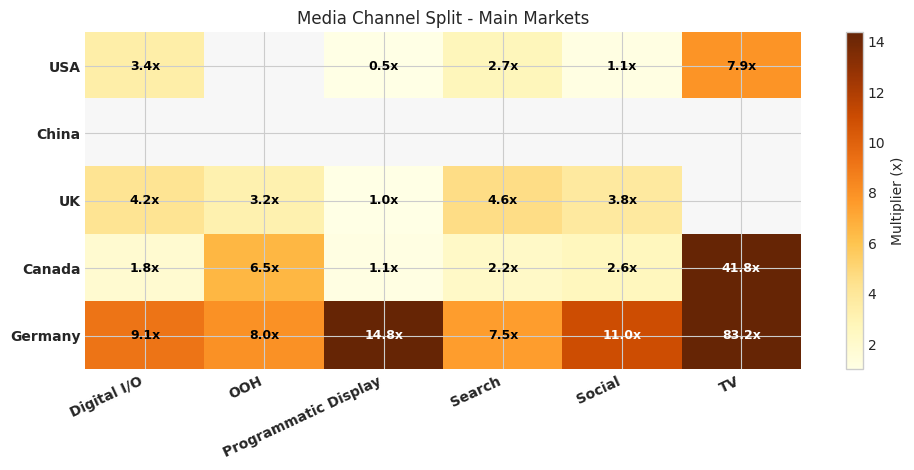

In [ ]:
# 2) Media channel split overall and by main market
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
MAPPE = Path('/home/ali/repos/porsche/budget_setting/highlight_budget_estimation/budget_setting_amendment/Mappe1.xlsx')

df = pd.read_excel(MAPPE, sheet_name='2024', header=6)
df.columns = [str(c).strip() for c in df.columns]
df = df.rename(columns={'Brand':'brand_raw','Market':'market','Media':'media','Sum of 2024 CY (EUR)':'spend_eur'})[['brand_raw','market','media','spend_eur']]
df['spend_eur'] = pd.to_numeric(df['spend_eur'], errors='coerce')
for c in ['brand_raw','market','media']:
    df[c] = df[c].astype(str).str.strip()

df = df[df['spend_eur'].notna() & (df['spend_eur'] > 0)].copy()
split = df['brand_raw'].str.extract(r'^(?P<brand>.*?)\s*-\s*Tier\s*(?P<tier>\d+)$')
df['brand'] = split['brand'].str.strip()
df['tier'] = pd.to_numeric(split['tier'], errors='coerce')
df = df[df['tier'] == 1].copy()
df = df[~df['brand_raw'].str.contains('Total|Grand Total', case=False, na=False)].copy()
df = df[~df['market'].str.contains('Total', case=False, na=False)].copy()

porsche_markets = sorted(df.loc[df['brand'].str.upper() == 'PORSCHE', 'market'].unique())
df = df[df['market'].isin(porsche_markets)].copy()
main_markets = (df[df['brand'].str.upper()=='PORSCHE'].groupby('market', as_index=False)['spend_eur'].sum().sort_values('spend_eur', ascending=False).head(5)['market'].tolist())

# overall: Porsche vs avg VW competitor by channel (multiplier)
p = df[df['brand'].str.upper()=='PORSCHE'].groupby('media', as_index=False)['spend_eur'].sum().rename(columns={'spend_eur':'porsche'})
c = df[df['brand'].str.upper()!='PORSCHE'].groupby(['media','brand'], as_index=False)['spend_eur'].sum()
c = c.groupby('media', as_index=False)['spend_eur'].mean().rename(columns={'spend_eur':'comp_avg'})
ov = p.merge(c, on='media', how='inner')
ov['multiplier'] = ov['comp_avg'] / ov['porsche']
ov = ov.sort_values('multiplier', ascending=False).head(8)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(ov['media'][::-1], ov['multiplier'][::-1], color='#0B5FFF')
ax.axvline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Multiplier (avg VW competitor / Porsche)')
ax.set_title('Media Channel Split - Overall')
plt.tight_layout()
plt.show()

# main markets heatmap (aggregated as requested)
pm = df[(df['brand'].str.upper()=='PORSCHE') & (df['market'].isin(main_markets))].groupby(['market','media'], as_index=False)['spend_eur'].sum().rename(columns={'spend_eur':'porsche'})
cm = df[(df['brand'].str.upper()!='PORSCHE') & (df['market'].isin(main_markets))].groupby(['market','media','brand'], as_index=False)['spend_eur'].sum()
cm = cm.groupby(['market','media'], as_index=False)['spend_eur'].mean().rename(columns={'spend_eur':'comp_avg'})
mm = pm.merge(cm, on=['market','media'], how='inner')
mm['multiplier'] = mm['comp_avg'] / mm['porsche']

keep_channels = (pm.groupby('media', as_index=False)['porsche'].sum().sort_values('porsche', ascending=False).head(6)['media'].tolist())
mm = mm[mm['media'].isin(keep_channels)]
mat = mm.pivot_table(index='market', columns='media', values='multiplier', aggfunc='mean').reindex(main_markets)

vmin = np.nanpercentile(mat.values, 5)
vmax = np.nanpercentile(mat.values, 90)
cmat = mat.clip(vmin, vmax)

fig, ax = plt.subplots(figsize=(10, 4.8), facecolor='white')
cmap = plt.cm.YlOrBr.copy()
cmap.set_bad('#f7f7f7')
im = ax.imshow(cmat.values, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
ax.set_xticks(np.arange(len(mat.columns)))
ax.set_xticklabels(mat.columns, rotation=25, ha='right', fontweight='bold')
ax.set_yticks(np.arange(len(mat.index)))
ax.set_yticklabels(mat.index, fontweight='bold')
ax.set_title('Media Channel Split - Main Markets')
for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat.values[i, j]
        if pd.notna(val):
            ax.text(j, i, f'{val:.1f}x', ha='center', va='center', color=('black' if val < 10 else 'white'), fontweight='bold', fontsize=9)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Multiplier (x)')
plt.tight_layout()
plt.show()

In [ ]:
# 3) Funnel stage split overall, and by main market
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
MAPPE = Path('/home/ali/repos/porsche/budget_setting/highlight_budget_estimation/budget_setting_amendment/Mappe1.xlsx')

stage_map = {
    'Search': 'LOWER',
    'Social': 'MIDDLE', 'Display': 'MIDDLE', 'Digital I/O': 'MIDDLE', 'Other': 'MIDDLE',
    'Dig. Video': 'UPPER', 'Video': 'UPPER', 'Programmatic Video': 'UPPER',
    'TV': 'UPPER', 'Print': 'UPPER', 'OOH': 'UPPER', 'Radio': 'UPPER', 'Cinema': 'UPPER'
}

df = pd.read_excel(MAPPE, sheet_name='2024', header=6)
df.columns = [str(c).strip() for c in df.columns]
df = df.rename(columns={'Brand':'brand_raw','Market':'market','Media':'media','Sum of 2024 CY (EUR)':'spend_eur'})[['brand_raw','market','media','spend_eur']]
df['spend_eur'] = pd.to_numeric(df['spend_eur'], errors='coerce')
for c in ['brand_raw','market','media']:
    df[c] = df[c].astype(str).str.strip()

df = df[df['spend_eur'].notna() & (df['spend_eur'] > 0)].copy()
split = df['brand_raw'].str.extract(r'^(?P<brand>.*?)\s*-\s*Tier\s*(?P<tier>\d+)$')
df['brand'] = split['brand'].str.strip()
df['tier'] = pd.to_numeric(split['tier'], errors='coerce')
df = df[df['tier'] == 1].copy()
df = df[~df['brand_raw'].str.contains('Total|Grand Total', case=False, na=False)].copy()
df = df[~df['market'].str.contains('Total', case=False, na=False)].copy()

porsche_markets = sorted(df.loc[df['brand'].str.upper() == 'PORSCHE', 'market'].unique())
df = df[df['market'].isin(porsche_markets)].copy()
main_markets = (df[df['brand'].str.upper()=='PORSCHE'].groupby('market', as_index=False)['spend_eur'].sum().sort_values('spend_eur', ascending=False).head(5)['market'].tolist())

df['stage'] = df['media'].map(stage_map).fillna('MIDDLE')
stages = ['LOWER','MIDDLE','UPPER']

# overall by brand (clean: Porsche + top 4 competitors)
brand_rank = df[df['brand'].str.upper()!='PORSCHE'].groupby('brand', as_index=False)['spend_eur'].sum().sort_values('spend_eur', ascending=False)
keep = ['PORSCHE'] + brand_rank.head(4)['brand'].tolist()
sub = df[df['brand'].isin(keep)].copy()

mat = sub.groupby(['stage','brand'], as_index=False)['spend_eur'].sum().pivot(index='stage', columns='brand', values='spend_eur').fillna(0).reindex(stages)
# convert to multiplier vs Porsche stage spend
for c in mat.columns:
    if c != 'PORSCHE':
        mat[c] = mat[c] / mat['PORSCHE']
mat = mat.drop(columns=['PORSCHE'])

x = np.arange(len(mat.index))
n = len(mat.columns)
width = min(0.8 / n, 0.18)
fig, ax = plt.subplots(figsize=(10.5, 4.8))
colors = plt.cm.Set2(np.linspace(0, 1, n))
for i, c in enumerate(mat.columns):
    off = (i - (n - 1) / 2) * width
    ax.bar(x + off, mat[c].values, width=width, label=c, color=colors[i])

ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.set_ylabel('Multiplier vs Porsche (x)')
ax.set_title('Funnel Stage Split - Overall')
ax.legend(frameon=False, ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

# main markets (stacked style not cluttered): avg competitor multiplier by stage
p = df[(df['brand'].str.upper()=='PORSCHE') & (df['market'].isin(main_markets))].groupby(['market','stage'], as_index=False)['spend_eur'].sum().rename(columns={'spend_eur':'porsche'})
c = df[(df['brand'].str.upper()!='PORSCHE') & (df['market'].isin(main_markets))].groupby(['market','stage','brand'], as_index=False)['spend_eur'].sum()
c = c.groupby(['market','stage'], as_index=False)['spend_eur'].mean().rename(columns={'spend_eur':'comp_avg'})
ms = p.merge(c, on=['market','stage'], how='inner')
ms['multiplier'] = ms['comp_avg'] / ms['porsche']
ms['stage'] = pd.Categorical(ms['stage'], categories=stages, ordered=True)
mat2 = ms.pivot(index='market', columns='stage', values='multiplier').reindex(main_markets)

fig, ax = plt.subplots(figsize=(10.5, 4.8))
x = np.arange(len(mat2.index))
w = 0.24
ax.bar(x - w, mat2['LOWER'], width=w, label='LOWER', color='#1f77b4')
ax.bar(x,     mat2['MIDDLE'], width=w, label='MIDDLE', color='#ff7f0e')
ax.bar(x + w, mat2['UPPER'], width=w, label='UPPER', color='#2ca02c')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(mat2.index, rotation=20)
ax.set_ylabel('Multiplier (x)')
ax.set_title('Funnel Stage Split - Main Markets')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

KeyError: 'PORSCHE'

In [ ]:
# 1) Comparative spend by market (ALL Tier 1 brands, big markets only)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
MAPPE = Path('/home/ali/repos/porsche/budget_setting/highlight_budget_estimation/budget_setting_amendment/Mappe1.xlsx')

df = pd.read_excel(MAPPE, sheet_name='2024', header=6)
df.columns = [str(c).strip() for c in df.columns]
df = df.rename(columns={'Brand':'brand_raw','Market':'market','Media':'media','Sum of 2024 CY (EUR)':'spend_eur'})[['brand_raw','market','media','spend_eur']]
for c in ['brand_raw','market','media']:
    df[c] = df[c].astype(str).str.strip()
df['spend_eur'] = pd.to_numeric(df['spend_eur'], errors='coerce')
df = df[df['spend_eur'].notna() & (df['spend_eur'] > 0)].copy()

split = df['brand_raw'].str.extract(r'^(?P<brand>.*?)\s*-\s*Tier\s*(?P<tier>\d+)$')
df['brand'] = split['brand'].str.strip()
df['tier'] = pd.to_numeric(split['tier'], errors='coerce')
df = df[df['tier'] == 1].copy()
df = df[~df['brand_raw'].str.contains('Total|Grand Total', case=False, na=False)]
df = df[~df['market'].str.contains('Total', case=False, na=False)]

porsche_markets = sorted(df.loc[df['brand'].str.upper() == 'PORSCHE', 'market'].unique())
df = df[df['market'].isin(porsche_markets)].copy()

# big markets = top 5 by Porsche spend
main_markets = (
    df[df['brand'].str.upper() == 'PORSCHE']
    .groupby('market', as_index=False)['spend_eur'].sum()
    .sort_values('spend_eur', ascending=False)
    .head(5)['market']
    .tolist()
)
plot = df[df['market'].isin(main_markets)].copy()

mat = plot.groupby(['market','brand'], as_index=False)['spend_eur'].sum().pivot(index='market', columns='brand', values='spend_eur').fillna(0)
mat = mat.reindex(main_markets)

# Porsche first
cols = ['PORSCHE'] + [c for c in mat.columns if c != 'PORSCHE']
mat = mat[[c for c in cols if c in mat.columns]] / 1e6

x = np.arange(len(mat.index))
n = len(mat.columns)
width = min(0.82 / n, 0.12)
colors = ['#111111'] + list(plt.cm.tab20(np.linspace(0, 1, max(n - 1, 1))))

fig, ax = plt.subplots(figsize=(16, 6))
for i, c in enumerate(mat.columns):
    off = (i - (n - 1) / 2) * width
    ax.bar(x + off, mat[c].values, width=width, label=c, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(mat.index, rotation=20)
ax.set_ylabel('Spend (EUR m)')
ax.set_title('Comparative Spend by Market')
ax.set_yscale('log')
ax.legend(frameon=False, ncol=4, fontsize=8, loc='upper left', bbox_to_anchor=(1.01,1))
plt.tight_layout()
plt.show()

In [ ]:
# 4) For each market: funnel stages for each brand
market_stage_brand = df.groupby(['market', 'funnel_stage', 'brand'], as_index=False)['spend_eur'].sum()

n_cols = 3
n_rows = math.ceil(len(markets) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows), squeeze=False)
axes = axes.flatten()

x = np.arange(len(stages))
n_brands = len(brands)
width = min(0.82 / max(n_brands, 1), 0.12)
palette = plt.cm.tab20(np.linspace(0, 1, max(n_brands, 1)))

for i, m in enumerate(markets):
    ax = axes[i]
    sub = market_stage_brand[market_stage_brand['market'] == m]
    mat = sub.pivot_table(index='funnel_stage', columns='brand', values='spend_eur', aggfunc='sum').reindex(stages).fillna(0)
    mat = mat.reindex(columns=brands, fill_value=0) / 1e6

    for j, b in enumerate(brands):
        offset = (j - (n_brands - 1) / 2) * width
        color = '#111111' if b == 'PORSCHE' else palette[j]
        ax.bar(x + offset, mat[b].values, width=width, color=color, label=b if i == 0 else None)

    ax.set_title(m)
    ax.set_xticks(x)
    ax.set_xticklabels(stages)
    ax.set_yscale('log')
    ax.set_ylabel('EUR m (log)')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=min(6, len(labels)), frameon=False)
fig.suptitle('Funnel Stages by Brand for Each Market', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# 2) Media channel split overall and by main market (ALL Tier 1 brands, no multipliers)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
MAPPE = Path('/home/ali/repos/porsche/budget_setting/highlight_budget_estimation/budget_setting_amendment/Mappe1.xlsx')

df = pd.read_excel(MAPPE, sheet_name='2024', header=6)
df.columns = [str(c).strip() for c in df.columns]
df = df.rename(columns={'Brand':'brand_raw','Market':'market','Media':'media','Sum of 2024 CY (EUR)':'spend_eur'})[['brand_raw','market','media','spend_eur']]
for c in ['brand_raw','market','media']:
    df[c] = df[c].astype(str).str.strip()
df['spend_eur'] = pd.to_numeric(df['spend_eur'], errors='coerce')
df = df[df['spend_eur'].notna() & (df['spend_eur'] > 0)].copy()

split = df['brand_raw'].str.extract(r'^(?P<brand>.*?)\s*-\s*Tier\s*(?P<tier>\d+)$')
df['brand'] = split['brand'].str.strip()
df['tier'] = pd.to_numeric(split['tier'], errors='coerce')
df = df[df['tier'] == 1].copy()
df = df[~df['brand_raw'].str.contains('Total|Grand Total', case=False, na=False)]
df = df[~df['market'].str.contains('Total', case=False, na=False)]

porsche_markets = sorted(df.loc[df['brand'].str.upper() == 'PORSCHE', 'market'].unique())
df = df[df['market'].isin(porsche_markets)].copy()
main_markets = (
    df[df['brand'].str.upper() == 'PORSCHE']
    .groupby('market', as_index=False)['spend_eur'].sum()
    .sort_values('spend_eur', ascending=False)
    .head(5)['market'].tolist()
)

# overall by channel with brands as columns (Porsche included)
ov = df.groupby(['media','brand'], as_index=False)['spend_eur'].sum().pivot(index='media', columns='brand', values='spend_eur').fillna(0)
# keep top 7 channels by Porsche spend for readability
if 'PORSCHE' in ov.columns:
    ch_order = ov['PORSCHE'].sort_values(ascending=False).head(7).index.tolist()
else:
    ch_order = ov.sum(axis=1).sort_values(ascending=False).head(7).index.tolist()
ov = ov.loc[ch_order]

cols = ['PORSCHE'] + [c for c in ov.columns if c != 'PORSCHE']
ov = ov[[c for c in cols if c in ov.columns]] / 1e6

x = np.arange(len(ov.index))
n = len(ov.columns)
width = min(0.82 / n, 0.1)
colors = ['#111111'] + list(plt.cm.tab20(np.linspace(0, 1, max(n - 1, 1))))

fig, ax = plt.subplots(figsize=(16, 6))
for i, c in enumerate(ov.columns):
    off = (i - (n - 1) / 2) * width
    ax.bar(x + off, ov[c].values, width=width, label=c, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(ov.index, rotation=25, ha='right')
ax.set_ylabel('Spend (EUR m)')
ax.set_title('Media Channel Split - Overall')
ax.set_yscale('log')
ax.legend(frameon=False, ncol=4, fontsize=8, loc='upper left', bbox_to_anchor=(1.01,1))
plt.tight_layout()
plt.show()

# by main market heatmap (aggregated spend of non-Porsche brands vs Porsche already noisy with all brands)
# keep heatmap simple: absolute spend by channel (all brands combined) for main markets
hm = df[df['market'].isin(main_markets)].groupby(['market','media'], as_index=False)['spend_eur'].sum()
# keep top channels by total spend
top_channels = hm.groupby('media', as_index=False)['spend_eur'].sum().sort_values('spend_eur', ascending=False).head(6)['media'].tolist()
hm = hm[hm['media'].isin(top_channels)]
hm_mat = hm.pivot(index='market', columns='media', values='spend_eur').reindex(main_markets)

fig, ax = plt.subplots(figsize=(10, 4.8), facecolor='white')
im = ax.imshow(hm_mat.values / 1e6, aspect='auto', cmap='YlOrBr')
ax.set_xticks(np.arange(len(hm_mat.columns)))
ax.set_xticklabels(hm_mat.columns, rotation=25, ha='right', fontweight='bold')
ax.set_yticks(np.arange(len(hm_mat.index)))
ax.set_yticklabels(hm_mat.index, fontweight='bold')
ax.set_title('Media Channel Split - Main Markets')
for spine in ax.spines.values():
    spine.set_visible(False)
for i in range(hm_mat.shape[0]):
    for j in range(hm_mat.shape[1]):
        v = hm_mat.values[i, j]
        if pd.notna(v):
            txt = f'{v/1e6:.1f}'
            color = 'black' if (v/1e6) < 10 else 'white'
            ax.text(j, i, txt, ha='center', va='center', fontweight='bold', fontsize=9, color=color)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Spend (EUR m)')
plt.tight_layout()
plt.show()

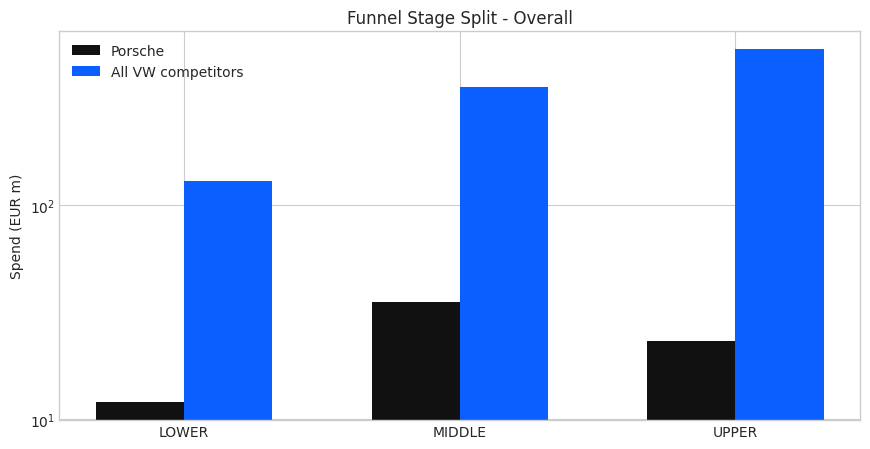

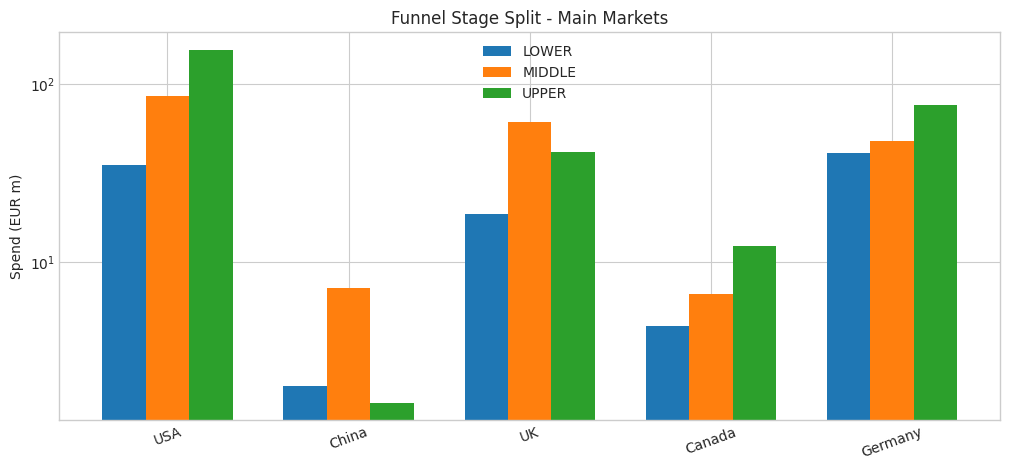

In [ ]:
# 3) Funnel stage split overall, and by main market (ALL Tier 1 brands)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
MAPPE = Path('/home/ali/repos/porsche/budget_setting/highlight_budget_estimation/budget_setting_amendment/Mappe1.xlsx')

stage_map = {
    'Search': 'LOWER',
    'Social': 'MIDDLE', 'Display': 'MIDDLE', 'Digital I/O': 'MIDDLE', 'Other': 'MIDDLE',
    'Dig. Video': 'UPPER', 'Video': 'UPPER', 'Programmatic Video': 'UPPER',
    'TV': 'UPPER', 'Print': 'UPPER', 'OOH': 'UPPER', 'Radio': 'UPPER', 'Cinema': 'UPPER'
}
stages = ['LOWER', 'MIDDLE', 'UPPER']

df = pd.read_excel(MAPPE, sheet_name='2024', header=6)
df.columns = [str(c).strip() for c in df.columns]
df = df.rename(columns={'Brand':'brand_raw','Market':'market','Media':'media','Sum of 2024 CY (EUR)':'spend_eur'})[['brand_raw','market','media','spend_eur']]
for c in ['brand_raw','market','media']:
    df[c] = df[c].astype(str).str.strip()
df['spend_eur'] = pd.to_numeric(df['spend_eur'], errors='coerce')
df = df[df['spend_eur'].notna() & (df['spend_eur'] > 0)].copy()

split = df['brand_raw'].str.extract(r'^(?P<brand>.*?)\s*-\s*Tier\s*(?P<tier>\d+)$')
df['brand'] = split['brand'].str.strip()
df['tier'] = pd.to_numeric(split['tier'], errors='coerce')
df = df[df['tier'] == 1].copy()
df = df[~df['brand_raw'].str.contains('Total|Grand Total', case=False, na=False)]
df = df[~df['market'].str.contains('Total', case=False, na=False)]

df['stage'] = df['media'].map(stage_map).fillna('MIDDLE')

# markets where Porsche exists + top 5 by Porsche spend
porsche_markets = sorted(df.loc[df['brand'].str.upper() == 'PORSCHE', 'market'].unique())
df = df[df['market'].isin(porsche_markets)].copy()
main_markets = (
    df[df['brand'].str.upper() == 'PORSCHE']
    .groupby('market', as_index=False)['spend_eur'].sum()
    .sort_values('spend_eur', ascending=False)
    .head(5)['market'].tolist()
)

# overall chart: all brands side-by-side per stage (absolute spend)
overall = (
    df.groupby(['stage', 'brand'], as_index=False)['spend_eur'].sum()
      .pivot(index='stage', columns='brand', values='spend_eur')
      .reindex(stages)
      .fillna(0) / 1e6
)
cols = ['PORSCHE'] + [c for c in overall.columns if c != 'PORSCHE']
overall = overall[[c for c in cols if c in overall.columns]]

x = np.arange(len(overall.index))
n = len(overall.columns)
width = min(0.82 / max(n,1), 0.12)
colors = ['#111111'] + list(plt.cm.tab20(np.linspace(0, 1, max(n - 1, 1))))

fig, ax = plt.subplots(figsize=(16, 6))
for i, c in enumerate(overall.columns):
    off = (i - (n - 1) / 2) * width
    ax.bar(x + off, overall[c].values, width=width, label=c, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.set_ylabel('Spend (EUR m)')
ax.set_title('Funnel Stage Split - Overall')
ax.set_yscale('log')
ax.legend(frameon=False, ncol=4, fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

# main markets: all brands side-by-side by market-stage combination
ms = df[df['market'].isin(main_markets)].copy()
ms['key'] = ms['market'] + ' | ' + ms['stage']
key_order = [f'{m} | {s}' for m in main_markets for s in stages]

mat = (
    ms.groupby(['key', 'brand'], as_index=False)['spend_eur'].sum()
      .pivot(index='key', columns='brand', values='spend_eur')
      .reindex(key_order)
      .fillna(0) / 1e6
)
cols = ['PORSCHE'] + [c for c in mat.columns if c != 'PORSCHE']
mat = mat[[c for c in cols if c in mat.columns]]

x = np.arange(len(mat.index))
n = len(mat.columns)
width = min(0.82 / max(n,1), 0.08)
colors = ['#111111'] + list(plt.cm.tab20(np.linspace(0, 1, max(n - 1, 1))))

fig, ax = plt.subplots(figsize=(18, 7))
for i, c in enumerate(mat.columns):
    off = (i - (n - 1) / 2) * width
    ax.bar(x + off, mat[c].values, width=width, label=c, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(mat.index, rotation=60, ha='right')
ax.set_ylabel('Spend (EUR m)')
ax.set_title('Funnel Stage Split - Main Markets')
ax.set_yscale('log')
ax.legend(frameon=False, ncol=4, fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()